In [1]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Welcome to JupyROOT 6.28/04


In [ ]:
ROOT.EnableImplicitMT(10)

Lemos os datos 

In [3]:
pathdata = "/rxc_lustre/ivan.cambon/TrackCalibmu_AA_tuples/data/NeNe_2025/00319263_*_1.trackeff_muons_nene.root"

tdf = ROOT.RDataFrame("charmonium_mu_mu_Down_mup_Tag/DecayTree", pathdata)

Aplicamos os mesmos cortes que en OO (sistema de referencia por ser o que máis estatística ten)

In [4]:
dataMupDowntag_bkg = tdf.Filter("dimuon_BPVIP < 0.35 && dimuon_DOCA_12 < 0.5 &&  dimuon_PT > 2000 && mum_CHI2DOF < 1.5 && mum_P > 1000 && mum_PID_MU > 0 && mum_PT > 1500 && mup_CHI2DOF < 1.2")

Ploteamos para ver a diferencia entre os datos sen cortes a datos con cortes. Deberíase apreciar un pico na masa do J/psi

In [ ]:
# Crear histogramas (RResultPtr)
h_mass_before = tdf.Histo1D(("h_mass_before","Dimuon mass before cuts",100,2600,3600), "dimuon_M")
h_mass_after  = dataMupDowntag_bkg.Histo1D(("h_mass_after","Dimuon mass after cuts",100,2600,3600), "dimuon_M")

# Converter a TH1 reais
hist_before = h_mass_before.GetValue()
hist_after  = h_mass_after.GetValue()

# Debuxar
c = ROOT.TCanvas("c", "Dimuon mass", 800, 600)

hist_before.SetLineColor(ROOT.kBlack)
hist_before.SetLineWidth(2)

hist_after.SetLineColor(ROOT.kRed)
hist_after.SetLineWidth(2)

# Debuxamos normalizado
hist_after.DrawNormalized("HIST")
hist_before.DrawNormalized("HIST SAME")

# Lenda
leg = ROOT.TLegend(0.75, 0.8, 0.92, 0.92)
leg.AddEntry(hist_before, "Datos crus", "l")
leg.AddEntry(hist_after, "Datos post cortes", "l")
leg.Draw()

# Estilo LHCb
ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()

c.Draw()
c.SaveAs("dimuon_mass_Down_corte_vs_uncut.png")

Definimos a continuación os samples match (hai long track asociada, detectouno o Sci-Fi) e fail (non foi detectado polo Sci-Fi)

In [ ]:
match = dataMupDowntag_bkg.Filter("nMatch > 0")
fail = dataMupDowntag_bkg.Filter("nMatch == 0")
tag = dataMupDowntag_bkg

Ploteamos os samples para ver as súas formas

-------------------------
Set LHCb Style - May 2021
-------------------------


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file NeNe_match_vs_fail_Down.png has been created


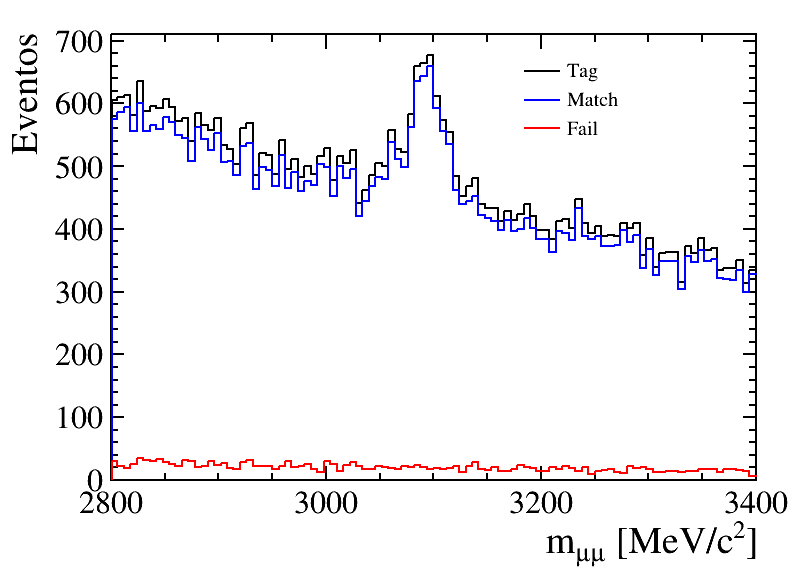

In [ ]:
c = ROOT.TCanvas("c", "", 800, 600)
h_tag   = dataMupDowntag_bkg.Histo1D(("tag","",100,2800,3400),"dimuon_M")
h_match = match.Histo1D(("match","",100,2800,3400),"dimuon_M")
h_fail  = fail.Histo1D(("fail","",100,2800,3400),"dimuon_M")

hist_tag   = h_tag.GetValue()
hist_match = h_match.GetValue()
hist_fail  = h_fail.GetValue()

hist_tag.SetLineColor(ROOT.kBlack)
hist_match.SetLineColor(ROOT.kBlue)
hist_fail.SetLineColor(ROOT.kRed)

hist_tag.GetXaxis().SetTitle("m_{#mu#mu} [MeV/c^{2}]")
hist_tag.GetYaxis().SetTitle("Eventos")
hist_tag.SetMinimum(0)
hist_tag.Draw("HIST")
hist_match.Draw("HIST SAME")
hist_fail.Draw("HIST SAME")

leg = ROOT.TLegend(0.65, 0.75, 0.9, 0.9)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.AddEntry(hist_tag,   "Tag",   "l")
leg.AddEntry(hist_match, "Match", "l")
leg.AddEntry(hist_fail,  "Fail",  "l")
leg.Draw()

ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()

c.Draw()
c.SaveAs("NeNe_match_vs_fail_Down.png")

Pasamos agora a facer os fits. Para traballar con RooFit primeiro temos que definir a variable que imos usar e ler os datos con ROOT.RooDataSet.from_numpy

In [6]:
mass = ROOT.RooRealVar("dimuon_M", "m(#mu#mu) [MeV/c^{2}]", 2800, 3400) 

data_match = match.AsNumpy(["dimuon_M"])
roo_data_match = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data_match["dimuon_M"]},
    [mass]
)

data_fail = fail.AsNumpy(["dimuon_M"])
roo_data_fail = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data_fail["dimuon_M"]},
    [mass])


data_tag = dataMupDowntag_bkg.AsNumpy(["dimuon_M"])
roo_data_tag = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data_tag["dimuon_M"]},
    [mass]
)

[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 28558 out-of-range events
[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 1355 out-of-range events
[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 29913 out-of-range events


Unha vez definida a variable de masa, pasamos cos fits. Para o sample match usamos un axuste a unha exponencial+gaussiana+CB

In [7]:
# SAMPLE MATCH
alpha = ROOT.RooRealVar("alpha", "alpha", 1.99966)
alpha.setConstant(True) # ¡Moi importante! Isto evita que MINUIT os toque
n = ROOT.RooRealVar("n", "n", 2.5)
n.setConstant(True)

# 3. Parámetros LIBRES (inicializados cos valores do MC pero con marxe)
mean   = ROOT.RooRealVar("mean", "mean", 3098.32, 3070, 3130)
# Damos un pouco máis de límite superior aos sigmas porque os datos reais teñen peor resolución
sigma1 = ROOT.RooRealVar("sigma1", "sigma gauss", 13.51, 5, 25)  
sigma2 = ROOT.RooRealVar("sigma2", "sigma cb", 26.76, 15, 300)
sig_frac = ROOT.RooRealVar("sig_frac", "fraction Gauss/CB", 0.714, 0, 1)

# 4. Construción do sinal
gauss = ROOT.RooGaussian("gauss", "Gaussian", mass, mean, sigma1)
cb    = ROOT.RooCBShape("cb", "Crystal Ball", mass, mean, sigma2, alpha, n)
signal = ROOT.RooAddPdf("signal", "Gauss + CB", [gauss, cb], [sig_frac])

# 5. Parámetros LIBRES do Fondo
tau = ROOT.RooRealVar("tau", "tau bkg", -0.0127, -1.0, 0.5)
bkg = ROOT.RooExponential("bkg", "Exponential Bkg", mass, tau)

# 6. Yields (Número de eventos). Subimos moito os límites iniciais porque tes máis datos
nsig = ROOT.RooRealVar("nsig", "N signal", 28000, 0, 200000)
nbkg = ROOT.RooRealVar("nbkg", "N background", 20000, 0, 200000)

# 7. Modelo Total e Axuste
model_total = ROOT.RooAddPdf("model_total", "Signal + Background", [signal, bkg], [nsig, nbkg])

# Asumindo que os teus datos de 'match' están nun RooDataSet ou RooDataHist chamado roo_data_match
model_total.fitTo(roo_data_match)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (gauss,cb,bkg)
 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 mean         3.09832e+03  6.00000e+00    3.07000e+03  3.13000e+03
     2 nbkg         2.00000e+04  1.00000e+04    0.00000e+00  2.00000e+05
     3 nsig         2.80000e+04  1.40000e+04    0.00000e+00  2.00000e+05
     4 sig_frac     7.14000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     5 sigma1       1.35100e+01  2.00000e+00    5.00000e+00  2.50000e+01
     6 sigma2       2.67600e+01  5.88000e+00    1.50000e+01  3.00000e+02
     7 tau         -1.27000e-02  1.50000e-01   -1.00000e+00  5.000

Para o tag usaremos tamén o combo de exponencial + gaussiana + CB xa que ten a mesma forma que o match

In [8]:
# SAMPLE TAG
alpha_tag = ROOT.RooRealVar("alpha", "alpha", 1.99966)
alpha_tag.setConstant(True)
n_tag = ROOT.RooRealVar("n", "n", 49.53)
n_tag.setConstant(True)

# 2. Parámetros LIBRES do Tag (Poden variar lixeiramente respecto ao match)
mean_tag   = ROOT.RooRealVar("mean_tag", "mean", 3098.32, 3070, 3130)
sigma1_tag = ROOT.RooRealVar("sigma1_tag", "sigma gauss", 13.51, 5, 25)  
sigma2_tag = ROOT.RooRealVar("sigma2_tag", "sigma cb", 26.76, 15, 60)
sig_frac_tag = ROOT.RooRealVar("sig_frac_tag", "fraction Gauss/CB", 0.714, 0, 1)

# Construción do sinal do Tag
gauss_tag = ROOT.RooGaussian("gauss_tag", "Gaussian", mass, mean_tag, sigma1_tag)
cb_tag    = ROOT.RooCBShape("cb_tag", "Crystal Ball", mass, mean_tag, sigma2_tag, alpha_tag, n_tag)
signal_tag = ROOT.RooAddPdf("signal_tag", "Gauss + CB", [gauss_tag, cb_tag], [sig_frac_tag])

# 3. Parámetros LIBRES do Fondo do Tag
tau_tag = ROOT.RooRealVar("tau_tag", "tau bkg", -0.01274, -1.0, 0.5)
bkg_tag = ROOT.RooExponential("bkg_tag", "Exponential Bkg", mass, tau_tag)

# 4. Yields (Número de eventos). Lixeiramente superiores porque Tag = Match + Fail
nsig_tag = ROOT.RooRealVar("nsig_tag", "N signal tag", 30000, 0, 300000)
nbkg_tag = ROOT.RooRealVar("nbkg_tag", "N background tag", 25000, 0, 300000)

# 5. Modelo Total e Axuste á mostra TAG
model_tag = ROOT.RooAddPdf("model_tag", "Signal + Background Tag", [signal_tag, bkg_tag], [nsig_tag, nbkg_tag])

# Lanzamos o fit contra os datos que me dixeches
model_tag.fitTo(roo_data_tag)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (gauss_tag,cb_tag,bkg_tag)
 **********
 **   11 **SET PRINT           1
 **********
 **********
 **   12 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 mean_tag     3.09832e+03  6.00000e+00    3.07000e+03  3.13000e+03
     2 nbkg_tag     2.50000e+04  1.25000e+04    0.00000e+00  3.00000e+05
     3 nsig_tag     3.00000e+04  1.50000e+04    0.00000e+00  3.00000e+05
     4 sig_frac_tag   7.14000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     5 sigma1_tag   1.35100e+01  2.00000e+00    5.00000e+00  2.50000e+01
     6 sigma2_tag   2.67600e+01  4.50000e+00    1.50000e+01  6.00000e+01
     7 tau_tag     -1.27400e-02  1.50000e-01   -1.00

Por último para o sample fail axustamos os datos a unha exponencial

In [9]:
# SAMPLE FAIL
#mass = ROOT.RooRealVar("mass", "m_{#mu#mu} [MeV/c^{2}]", 2800, 3400)

# 2. O parámetro da exponencial para o Fail
# Inicializámolo nun valor pequeno negativo.
tau_fail = ROOT.RooRealVar("tau_fail", "tau fail", -0.001, -0.02, 0.0)

# 3. A función Exponencial pura
bkg_fail = ROOT.RooExponential("bkg_fail", "Exponential Bkg Fail", mass, tau_fail)

# 4. Número de eventos (Yield). 
# Mirando a túa gráfica, a mostra fail ten moi poucos eventos en comparación co resto.
nbkg_fail = ROOT.RooRealVar("nbkg_fail", "N background fail", 1000, 0, 50000)

# 5. Creamos o modelo estendido. 
# Aínda que é unha soa función, metémola nun RooAddPdf para que MINUIT calcule o nbkg_fail
model_fail = ROOT.RooAddPdf("model_fail", "Background Only Fail", [bkg_fail], [nbkg_fail])

# 6. Lanzamos o fit (supoñendo que a túa variable de datos se chama roo_data_fail)
model_fail.fitTo(roo_data_fail)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (bkg_fail)
 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 nbkg_fail    1.00000e+03  5.00000e+02    0.00000e+00  5.00000e+04
     2 tau_fail    -1.00000e-03  5.00000e-04   -2.00000e-02  0.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        1000           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 

Ploteamos agora os datos xunto cos fits

[#1] INFO:Plotting -- RooPlot::updateFitRangeNorm: New event count of 45613 will supercede previous event count of 47647 for normalization of PDF projections
[#1] INFO:Plotting -- RooPlot::updateFitRangeNorm: New event count of 2034 will supercede previous event count of 45613 for normalization of PDF projections
-------------------------
Set LHCb Style - May 2021
-------------------------


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_final
Info in <TCanvas::Print>: png file Axustes_Down_NeNe.png has been created


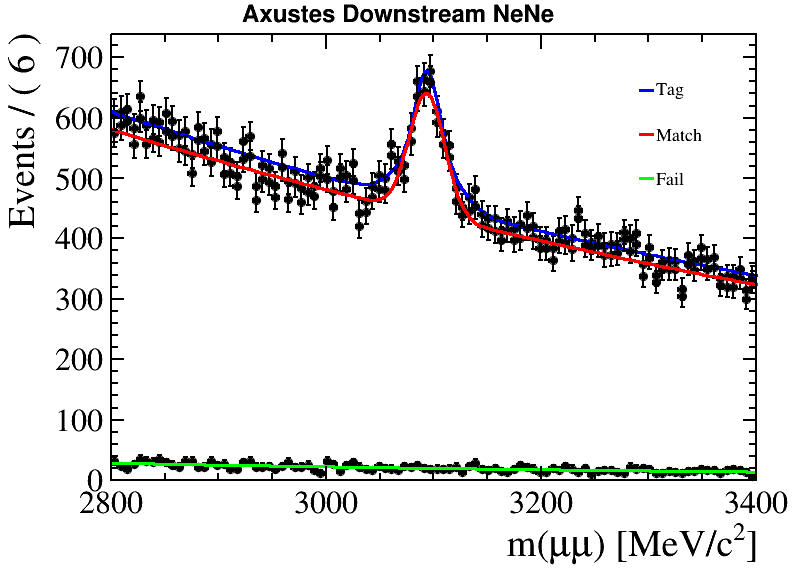

In [12]:
# Creamos o frame
frame_all = mass.frame(ROOT.RooFit.Title("Comparacion Tag vs Match vs Fail"))

# 1. TAG (Datos e modelo en NEGRO por defecto)
roo_data_tag.plotOn(frame_all, ROOT.RooFit.Name("DataTag")) 
model_tag.plotOn(frame_all, ROOT.RooFit.Name("ModelTag"))

# 2. MATCH (Datos e modelo en VERMELLO continuo)
roo_data_match.plotOn(frame_all, 
                      ROOT.RooFit.Name("DataMatch"), 
                      ROOT.RooFit.MarkerColor(ROOT.kBlack), 
                      ROOT.RooFit.LineColor(ROOT.kBlack)) 

model_total.plotOn(frame_all, 
                   ROOT.RooFit.Name("ModelMatch"), 
                   ROOT.RooFit.LineColor(ROOT.kRed)) 

# 3. FAIL (Datos e modelo en VERDE continuo)
roo_data_fail.plotOn(frame_all, 
                      ROOT.RooFit.Name("DataFail"), 
                      ROOT.RooFit.MarkerColor(ROOT.kBlack), 
                      ROOT.RooFit.LineColor(ROOT.kBlack))

model_fail.plotOn(frame_all, 
                   ROOT.RooFit.Name("ModelFail"), 
                   ROOT.RooFit.LineColor(ROOT.kGreen))

# Debuxamos
c_final = ROOT.TCanvas("c_final", "Canvas Final", 800, 600)
leg = ROOT.TLegend(0.80, 0.65, 0.90, 0.88)
leg.SetBorderSize(0)      # Quítalle o bordo negro á caixa para que quede máis pro
leg.SetFillStyle(0)       # Fai que o fondo da lenda sexa transparente
leg.SetTextSize(0.035)    # Tamaño da letra

# Engadimos os modelos usando os nomes exactos. 
# O "L" significa que queremos que na lenda se debuxe unha Liña.
leg.AddEntry(frame_all.findObject("ModelTag"), "Tag", "L")
leg.AddEntry(frame_all.findObject("ModelMatch"), "Match", "L")
leg.AddEntry(frame_all.findObject("ModelFail"), "Fail", "L")


ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()
frame_all.Draw()
leg.Draw("SAME")
c_final.Draw()
title_text = ROOT.TLatex()
title_text.SetNDC()              # Usa coordenadas da pantalla (0 a 1) no canto das dos eixes
title_text.SetTextSize(0.045)    # Tamaño do texto
title_text.SetTextFont(62)       # Tipo de letra (62 adoita ser negrita en ROOT)
title_text.SetTextAlign(21)      # Aliñación: 2 (centro horizontal), 1 (abaixo vertical)

# Debuxamos o título na posición X=0.5 (centro) e Y=0.92 (arriba do todo)
title_text.DrawLatex(0.5, 0.96, "Axustes Downstream NeNe")
c_final.SaveAs("Axustes_Down_NeNe.png")